# 01 — Probability Basics
**Week 2 | Mathematical Foundations for RL**

By the end of this notebook you will:
- Simulate discrete and continuous random variables
- Compute empirical mean, variance, and compare to theoretical values
- Visualise distributions and understand their shape

These are the building blocks for understanding stochastic rewards in RL.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Dice Simulation
A fair 6-sided die — simplest discrete random variable.

Empirical mean:     3.4999  (theoretical: 3.5000)
Empirical variance: 2.9194  (theoretical: 2.9167)


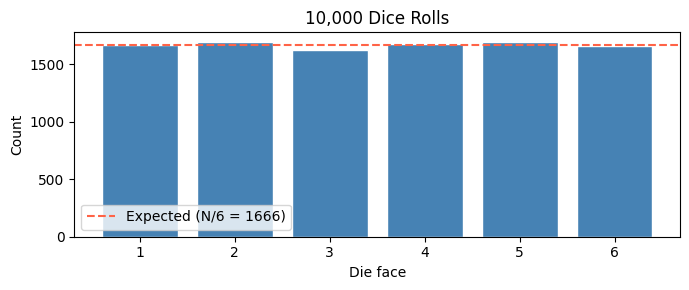

In [3]:
# Simulate N dice rolls
N = 10_000
rolls = np.random.randint(1, 7, size=N)

# Theoretical values
theoretical_mean = 3.5
theoretical_var  = 35/12  # (b-a+1)^2 - 1) / 12 for uniform discrete

print(f"Empirical mean:     {rolls.mean():.4f}  (theoretical: {theoretical_mean:.4f})")
print(f"Empirical variance: {rolls.var():.4f}  (theoretical: {theoretical_var:.4f})")

plt.figure(figsize=(7, 3))
counts, _, bars = plt.hist(rolls, bins=np.arange(0.5, 7.5, 1), edgecolor='white', color='steelblue', rwidth=0.8)
plt.axhline(N/6, color='tomato', linestyle='--', label=f'Expected (N/6 = {N//6})')
plt.xlabel('Die face'); plt.ylabel('Count'); plt.title('10,000 Dice Rolls')
plt.xticks(range(1,7)); plt.legend(); plt.tight_layout(); plt.show()

## 2. Continuous Distribution — Normal
Many RL reward signals are approximately Gaussian.

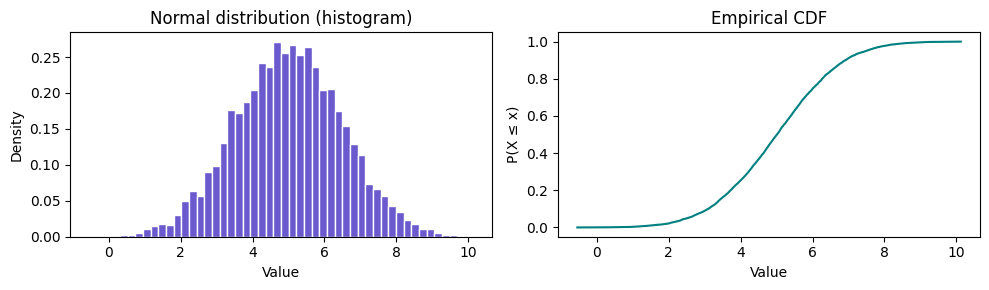

Mean: 5.002 (true: 5.0)
Std:  1.500  (true: 1.5)


In [4]:
mu, sigma = 5.0, 1.5
samples = np.random.normal(mu, sigma, size=N)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(samples, bins=50, color='slateblue', edgecolor='white', density=True)
axes[0].set_title('Normal distribution (histogram)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')

# Empirical CDF
sorted_s = np.sort(samples)
cdf = np.arange(1, N+1) / N
axes[1].plot(sorted_s, cdf, color='teal', linewidth=1.5)
axes[1].set_title('Empirical CDF')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('P(X ≤ x)')
plt.tight_layout(); plt.show()

print(f"Mean: {samples.mean():.3f} (true: {mu})")
print(f"Std:  {samples.std():.3f}  (true: {sigma})")

## 3. Expectation and Variance — Intuition
Expectation = centre of mass of the distribution.  
Variance = average squared distance from the mean (spread).

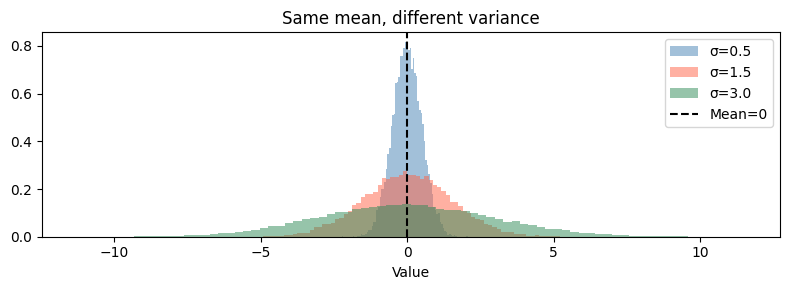

In [5]:
# Compare two distributions with same mean but different variance
fig, ax = plt.subplots(figsize=(8, 3))
for sigma_, color_, label_ in [(0.5,'steelblue','σ=0.5'), (1.5,'tomato','σ=1.5'), (3.0,'seagreen','σ=3.0')]:
    s = np.random.normal(0, sigma_, 20_000)
    ax.hist(s, bins=80, alpha=0.5, density=True, color=color_, label=label_)
ax.axvline(0, color='black', linestyle='--', label='Mean=0')
ax.set_title('Same mean, different variance'); ax.legend(); ax.set_xlabel('Value')
plt.tight_layout(); plt.show()

## 4. The Law of Large Numbers
As we collect more samples, the empirical mean converges to E[X].  
This is why RL agents improve with experience.

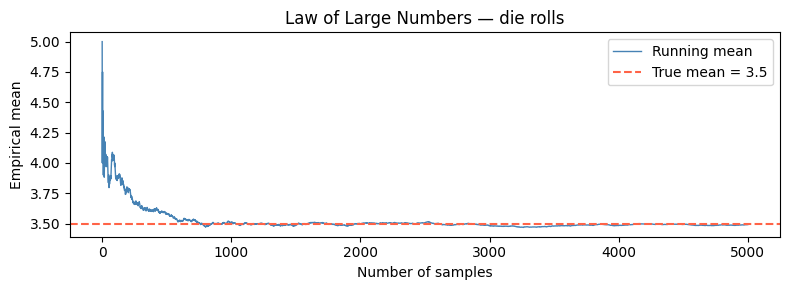

In [6]:
true_mean = 3.5
rolls_seq = np.random.randint(1, 7, size=5000)
running_mean = np.cumsum(rolls_seq) / np.arange(1, 5001)

plt.figure(figsize=(8, 3))
plt.plot(running_mean, color='steelblue', linewidth=1, label='Running mean')
plt.axhline(true_mean, color='tomato', linestyle='--', label=f'True mean = {true_mean}')
plt.xlabel('Number of samples'); plt.ylabel('Empirical mean')
plt.title('Law of Large Numbers — die rolls')
plt.legend(); plt.tight_layout(); plt.show()

## ✅ Exercise
1. Change `mu` and `sigma` in section 2. What happens to the histogram shape?
2. In section 4, replace dice rolls with samples from an exponential distribution (`np.random.exponential`). Does LLN still hold?
3. **Challenge**: simulate 1000 coin flips (0/1). Plot the running fraction of heads. What does it converge to?

### Changing the mu changes the value around which it would be centred. The value of sigma changes how "concentrated" the distribution is, ie how spread out or steep it is around the mean

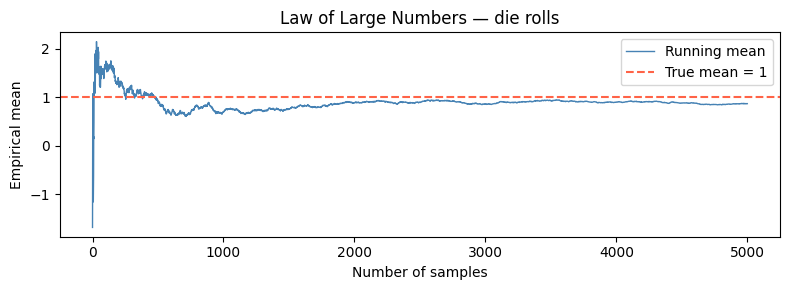

In [8]:
true_mean = 1
rolls_seq = np.random.normal(1, 7, size=5000)
running_mean = np.cumsum(rolls_seq) / np.arange(1, 5001)

plt.figure(figsize=(8, 3))
plt.plot(running_mean, color='steelblue', linewidth=1, label='Running mean')
plt.axhline(true_mean, color='tomato', linestyle='--', label=f'True mean = {true_mean}')
plt.xlabel('Number of samples'); plt.ylabel('Empirical mean')
plt.title('Law of Large Numbers — die rolls')
plt.legend(); plt.tight_layout(); plt.show()

##### Yes, it does hold as expected. Only difference is the the 1,7 are not the range of integers from which it is chosen

In [15]:
# Simulate N dice rolls
N_of_samples = 10000
size_array= [10,100,1000,10000,100000]
for sample in size_array:
    rolls = np.random.randint(0, 2, size=sample)
    # print(rolls)
    no_of_heads=rolls.sum() 
    print(no_of_heads)
    print("Theorectical value = ",sample/2)




# # Theoretical values
# theoretical_mean = 3.5
# theoretical_var  = 35/12  # (b-a+1)^2 - 1) / 12 for uniform discrete

# print(f"Empirical mean:     {rolls.mean():.4f}  (theoretical: {theoretical_mean:.4f})")
# print(f"Empirical variance: {rolls.var():.4f}  (theoretical: {theoretical_var:.4f})")

# plt.figure(figsize=(7, 3))
# counts, _, bars = plt.hist(rolls, bins=np.arange(0.5, 7.5, 1), edgecolor='white', color='steelblue', rwidth=0.8)
# plt.axhline(N/6, color='tomato', linestyle='--', label=f'Expected (N/6 = {N//6})')
# plt.xlabel('Die face'); plt.ylabel('Count'); plt.title('10,000 Dice Rolls')
# plt.xticks(range(1,7)); plt.legend(); plt.tight_layout(); plt.show()

2
Theorectical value =  5.0
51
Theorectical value =  50.0
497
Theorectical value =  500.0
5000
Theorectical value =  5000.0
50094
Theorectical value =  50000.0


### It converges to 1/2 of the total tosses as expected.